# Data Visualization & Analysis

**Goal:** Explore a cleaned dataset using histograms, scatterplots, correlation matrices, and
other charts (Matplotlib + Seaborn) to surface distributions, relationships, and outliers.

**Dataset:** Reusing / extending the cleaned dataset from Task 1 (Data Cleanup). Update
`DATA_PATH` and `COLUMN CONFIG` below to match the current version of that dataset — nothing
else in this notebook needs to change.

**Structure**
1. Setup & config
2. Load data + validation checks
3. Reusable plotting functions
4. Generate visualizations
5. Insights & observations


In [22]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
%matplotlib inline


## 1. Configuration

No hardcoded paths or column names below this point — everything the plotting code needs is defined here.

In [23]:
# --- Paths ---
# Jupyter often starts in your OS home folder, NOT this task folder — that is why
# a plain Path.cwd() can silently point at the wrong place. Confirm below.
PROJECT_ROOT = Path.cwd()
print(f"Current working directory: {PROJECT_ROOT}")

DATA_PATH = PROJECT_ROOT / "cleaned_employee_data.csv"
FIGURES_DIR = PROJECT_ROOT / "visualizations"
FIGURES_DIR.mkdir(exist_ok=True, parents=True)

# --- Column configuration ---
# Fill these in once for your dataset; every function below reads from here,
# so swapping datasets later never requires touching plotting code.
NUMERIC_COLS = ["age", "salary", "years_at_company", "performance_score", "projects_completed", "training_hours", "satisfaction_score", "salary_percentile_in_band"]
CATEGORICAL_COLS = ["gender", "department", "education_level", "remote_work", "seniority_band", "performance_tier"]
TARGET_COL = "performance_tier"

# --- Plot settings ---
FIGSIZE = (8, 5)
HIST_BINS = 30
DPI = 150

Current working directory: C:\Users\Eagle Trader's


## 2. Load Data

In [24]:
def load_data(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {path}. "
            "Check the 'Current working directory' printed in the config cell above -- "
            "if it is not your task folder, set PROJECT_ROOT explicitly there (see the "
            "commented-out line) and re-run from the top."
        )
    df = pd.read_csv(path)
    return df

df = load_data(DATA_PATH)

# If NUMERIC_COLS / CATEGORICAL_COLS were left empty, infer them as a starting point
if not NUMERIC_COLS:
    NUMERIC_COLS = df.select_dtypes(include=np.number).columns.tolist()
if not CATEGORICAL_COLS:
    CATEGORICAL_COLS = df.select_dtypes(exclude=np.number).columns.tolist()

print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Loaded 500 rows, 26 columns


,employee_id,full_name,age,gender,email,phone,department,job_title,salary,city,...,training_hours,satisfaction_score,last_promotion_year,manager_id,salary_range_min,salary_range_max,salary_range_mid,salary_percentile_in_band,seniority_band,performance_tier
0,E0001,Amber Hill,30,Male,curtishobbs@example.com,204-273-8437,Marketing,Marketing Manager,51639,New York,...,56,3.5,2024,E0045,50000,100000,75000,3.3,Principal,Below Average
1,E0002,Jessica Hernandez,43,Male,davidharris@example.org,392.413.2184x8777,Product,Ux Designer,97298,New York,...,92,7.3,2020,E0006,75000,140000,107500,34.3,Senior,Exceptional
2,E0003,Katherine Miller,45,Female,villanuevasamantha@example.com,687.904.7338,Hr,Hr Coordinator,51619,San Francisco,...,56,8.6,2019,E0021,45000,90000,67500,14.7,Senior,Needs Improvement
3,E0004,Anthony Johnston,58,Non-binary,cody75@example.com,245-937-4916x26102,Product,Product Owner,92546,Austin,...,35,1.8,2020,E0011,75000,140000,107500,27.0,Junior,Meets Expectations
4,E0005,Anna Ruiz,51,Female,ortizjohn@example.com,8515025368,Product,Product Manager,114086,San Francisco,...,184,3.4,2019,E0007,75000,140000,107500,60.1,Junior,Meets Expectations


## 3. Post-Load Validation Checks

Confirm the data is actually in the shape we expect before plotting anything.

In [25]:
def validate_dataframe(df: pd.DataFrame, numeric_cols: list, categorical_cols: list) -> None:
    missing_cols = [c for c in numeric_cols + categorical_cols if c not in df.columns]
    assert not missing_cols, f"Configured columns not found in dataframe: {missing_cols}"

    null_counts = df.isnull().sum()
    total_nulls = null_counts.sum()
    print("Null values per column:")
    print(null_counts[null_counts > 0] if total_nulls else "None — dataset is fully populated.")

    print("\nDtypes:")
    print(df.dtypes)

    for col in numeric_cols:
        assert pd.api.types.is_numeric_dtype(df[col]), f"{col} expected numeric, got {df[col].dtype}"

    print("\nValidation passed: configured numeric columns are numeric, no missing columns.")

validate_dataframe(df, NUMERIC_COLS, CATEGORICAL_COLS)


Null values per column:
None — dataset is fully populated.

Dtypes:
employee_id                   object
full_name                     object
age                            int64
gender                        object
email                         object
phone                         object
department                    object
job_title                     object
salary                         int64
city                          object
hire_date                     object
years_at_company               int64
performance_score            float64
education_level               object
remote_work                   object
projects_completed             int64
training_hours                 int64
satisfaction_score           float64
last_promotion_year            int64
manager_id                    object
salary_range_min               int64
salary_range_max               int64
salary_range_mid               int64
salary_percentile_in_band    float64
seniority_band                object
perform

## 4. Reusable Plotting Functions

Each function is parameterized — no column names are baked in — and saves its output to `FIGURES_DIR`.

In [26]:
def save_fig(fig, name: str) -> None:
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=DPI, bbox_inches="tight")


def plot_histograms(df: pd.DataFrame, columns: list, bins: int = HIST_BINS) -> None:
    for col in columns:
        fig, ax = plt.subplots(figsize=FIGSIZE)
        sns.histplot(data=df, x=col, bins=bins, kde=True, ax=ax)
        ax.set_title(f"Distribution of {col}")
        plt.tight_layout()
        save_fig(fig, f"hist_{col}")
        plt.show()


def plot_scatterplots(df: pd.DataFrame, x_col: str, y_col: str, hue: str = None) -> None:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    sns.scatterplot(data=df, x=x_col, y=y_col, hue=hue, ax=ax)
    ax.set_title(f"{y_col} vs {x_col}")
    plt.tight_layout()
    save_fig(fig, f"scatter_{x_col}_vs_{y_col}")
    plt.show()


def plot_correlation_matrix(df: pd.DataFrame, columns: list) -> None:
    corr = df[columns].corr()
    fig, ax = plt.subplots(figsize=(max(FIGSIZE[0], len(columns) * 0.8), max(FIGSIZE[1], len(columns) * 0.8)))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
    ax.set_title("Correlation Matrix")
    plt.tight_layout()
    save_fig(fig, "correlation_matrix")
    plt.show()


def plot_boxplots(df: pd.DataFrame, columns: list, by: str = None) -> None:
    for col in columns:
        fig, ax = plt.subplots(figsize=FIGSIZE)
        if by:
            sns.boxplot(data=df, x=by, y=col, ax=ax)
            ax.set_title(f"{col} by {by}")
        else:
            sns.boxplot(data=df, y=col, ax=ax)
            ax.set_title(f"Spread of {col}")
        plt.tight_layout()
        save_fig(fig, f"box_{col}" + (f"_by_{by}" if by else ""))
        plt.show()


def plot_pairwise(df: pd.DataFrame, columns: list, hue: str = None) -> None:
    grid = sns.pairplot(df[columns + ([hue] if hue and hue not in columns else [])], hue=hue)
    grid.fig.suptitle("Pairwise Relationships", y=1.02)
    grid.savefig(FIGURES_DIR / "pairplot.png", dpi=DPI, bbox_inches="tight")
    plt.show()


## 5. Generate Visualizations

Adjust the arguments below once the config section is filled in.

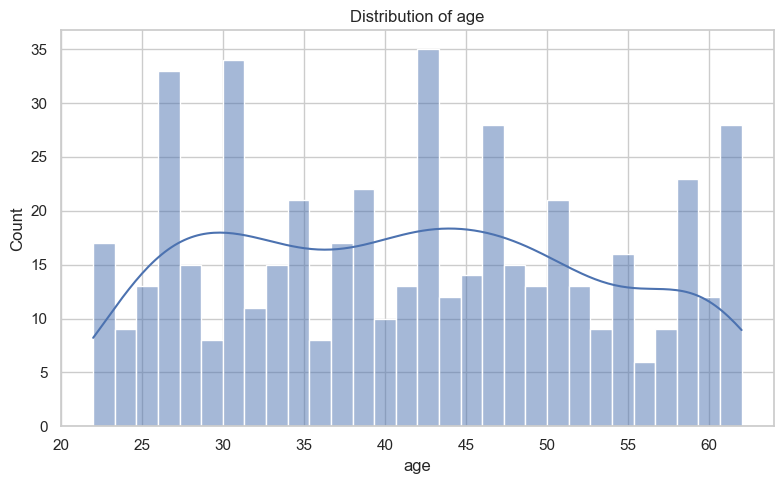

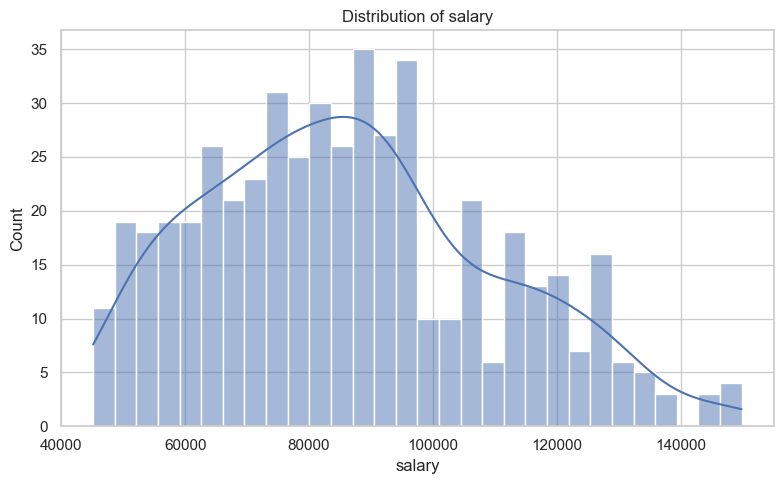

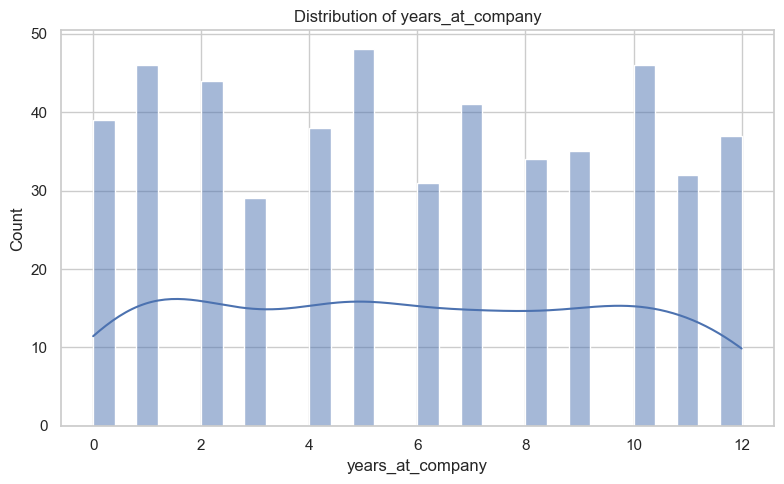

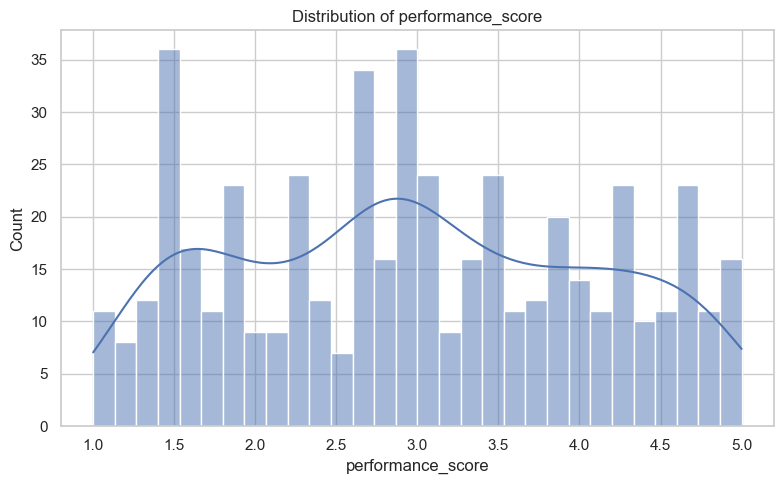

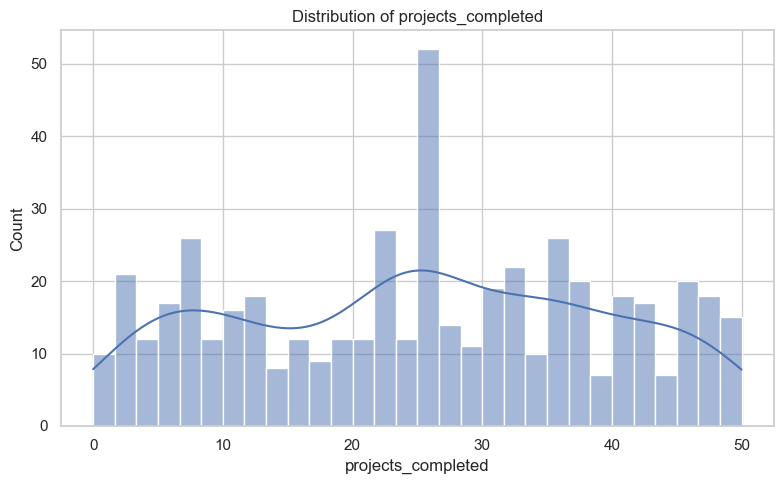

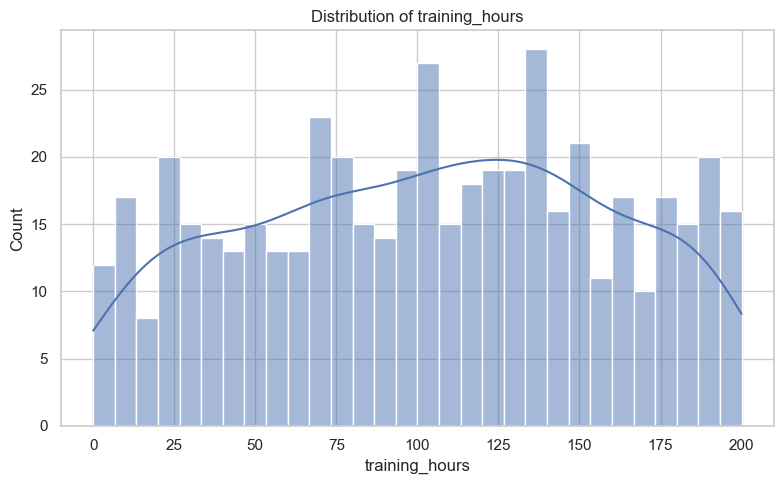

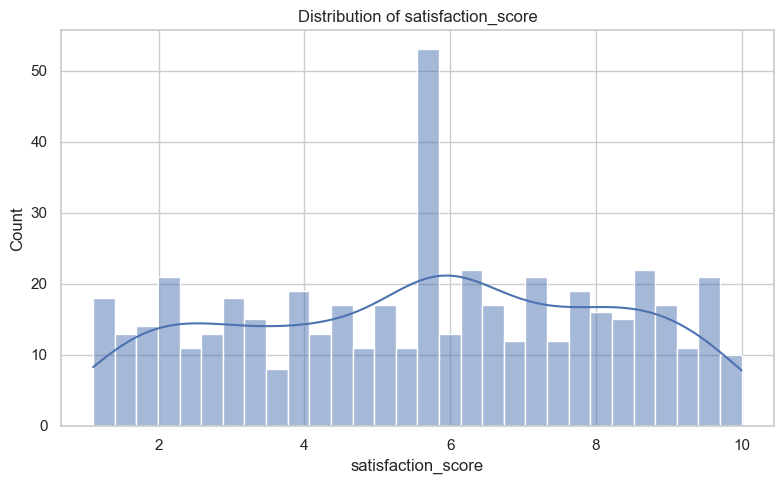

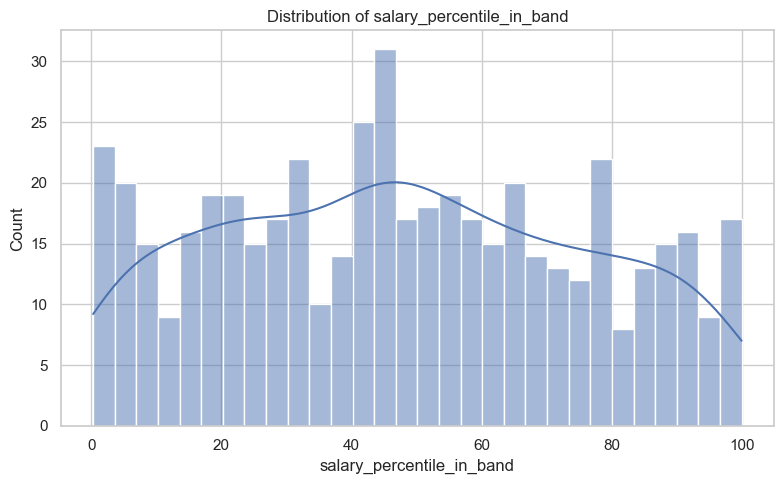

In [27]:
plot_histograms(df, NUMERIC_COLS)


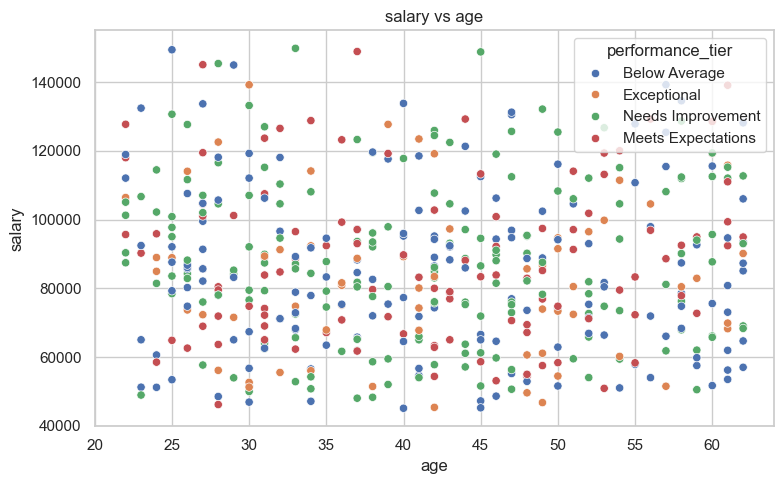

In [28]:
# Example — replace with two real numeric columns from your dataset
if len(NUMERIC_COLS) >= 2:
    plot_scatterplots(df, NUMERIC_COLS[0], NUMERIC_COLS[1], hue=TARGET_COL)


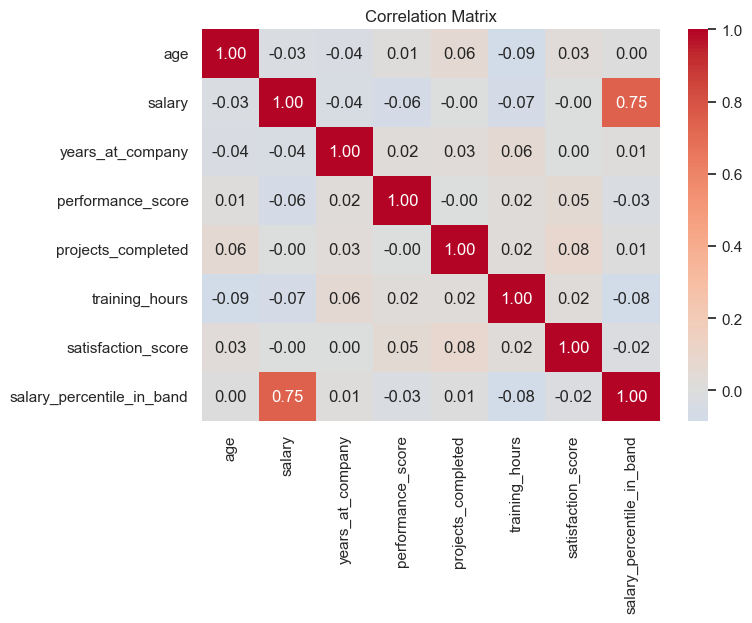

In [29]:
if len(NUMERIC_COLS) >= 2:
    plot_correlation_matrix(df, NUMERIC_COLS)


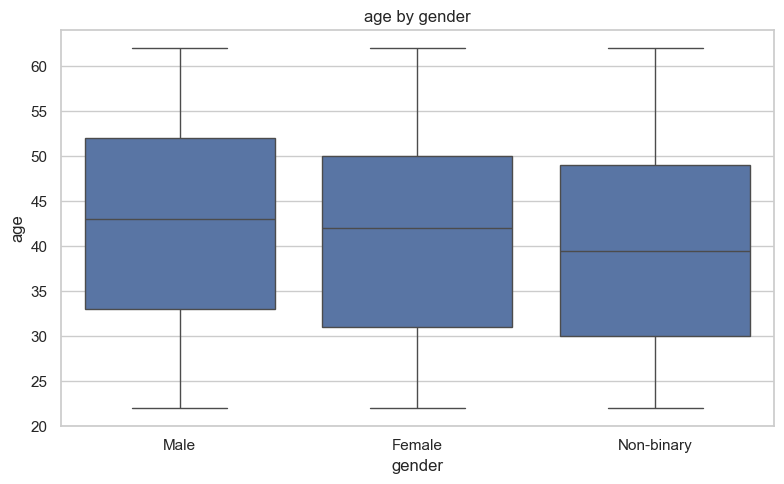

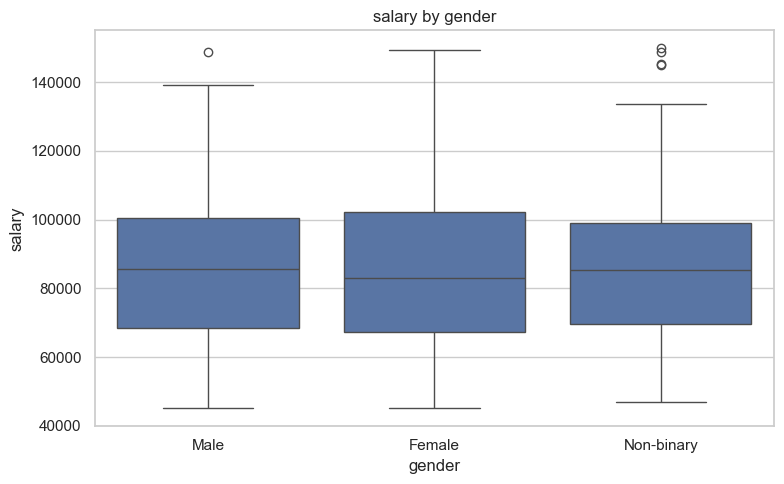

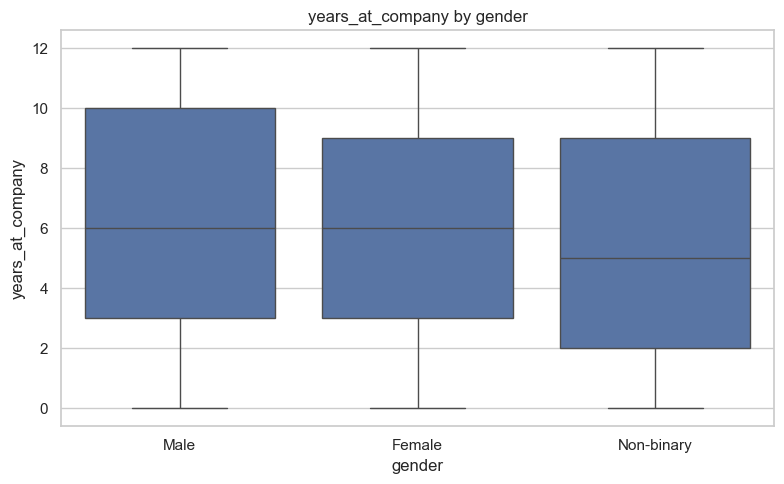

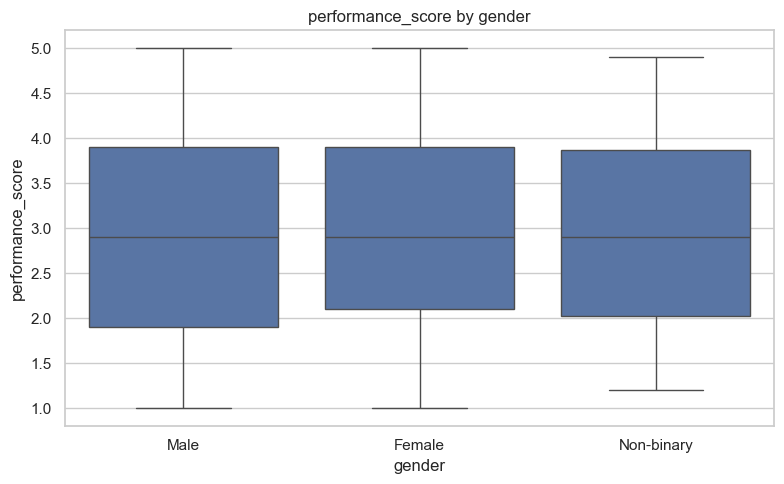

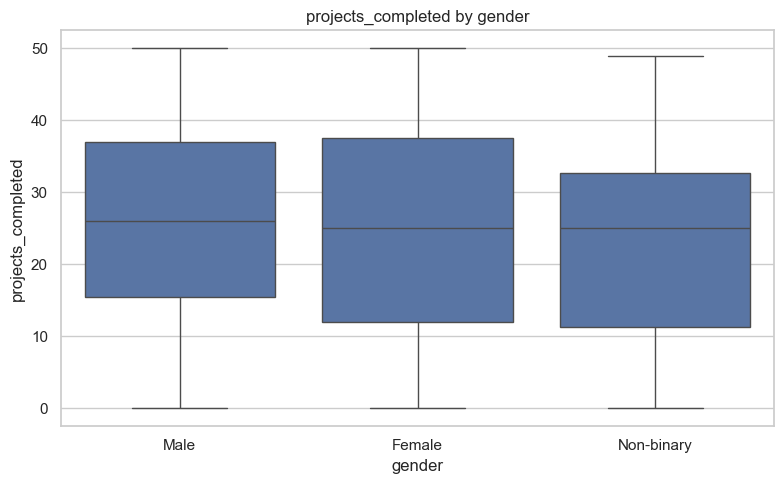

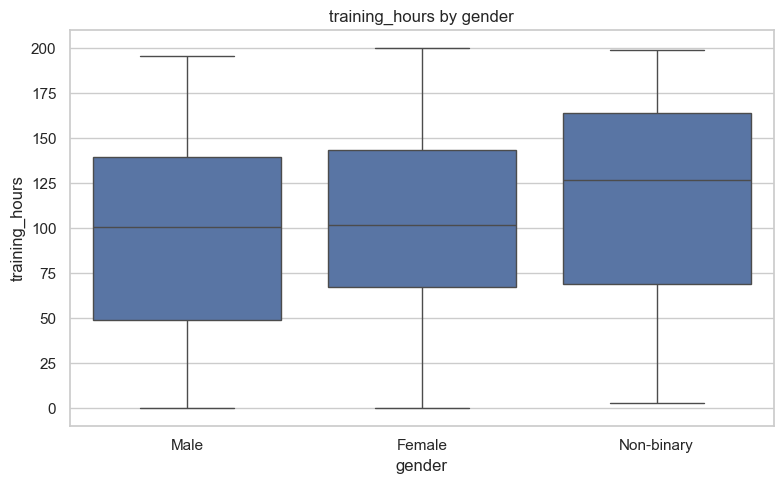

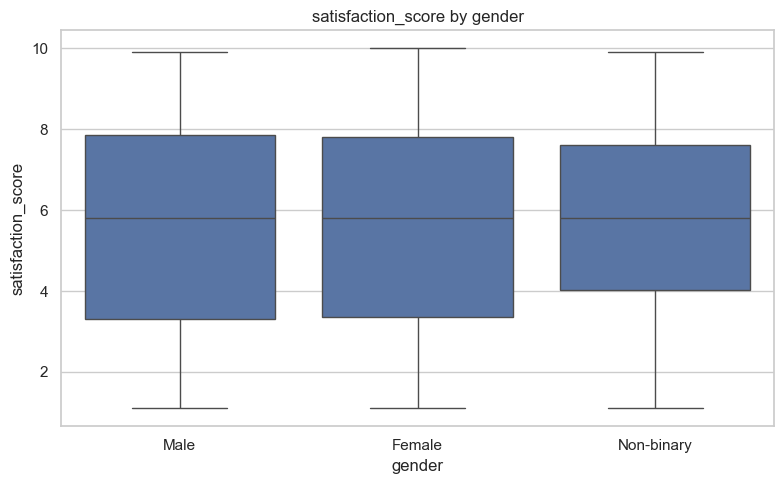

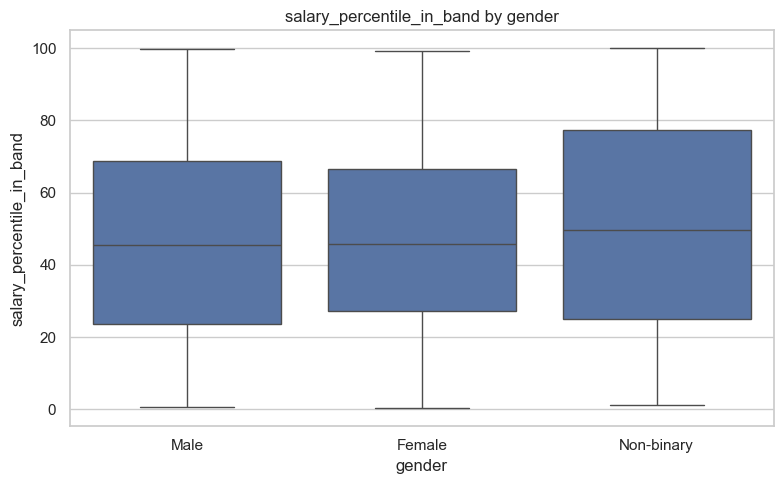

In [30]:
plot_boxplots(df, NUMERIC_COLS, by=CATEGORICAL_COLS[0] if CATEGORICAL_COLS else None)


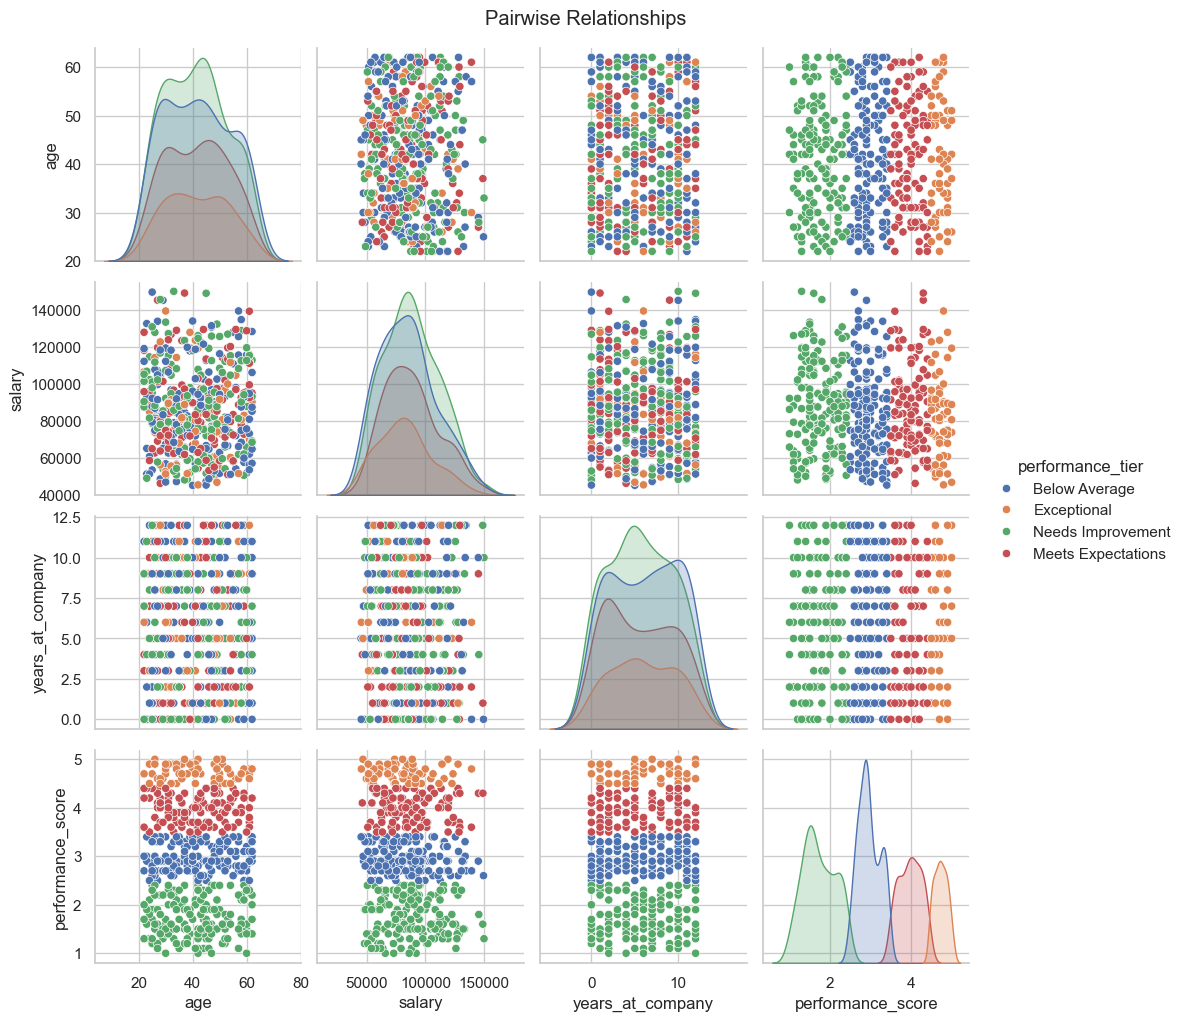

In [31]:
if len(NUMERIC_COLS) >= 2:
    plot_pairwise(df, NUMERIC_COLS[:4], hue=TARGET_COL)


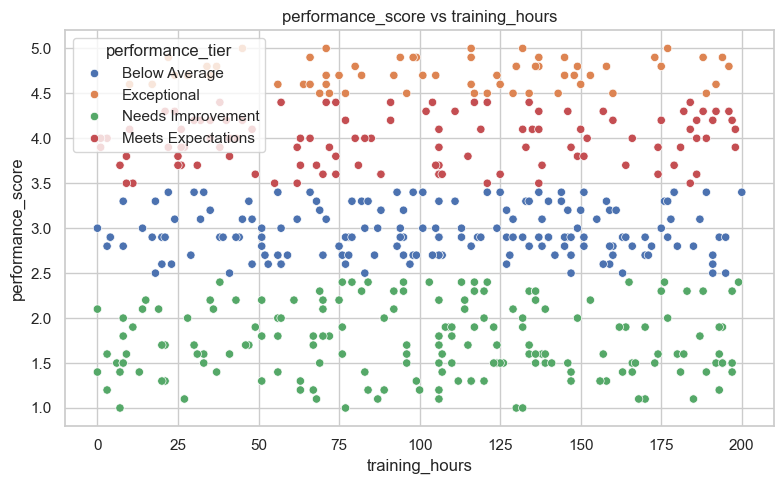

In [33]:
plot_scatterplots(df, "training_hours", "performance_score", hue=TARGET_COL)

## 6. Insights & Observations

- **Distributions:** Salary clusters in bands (mostly 70k-100k) rather than a smooth curve —
  likely tied to the dataset's fixed salary_range_min/max columns. Performance_score is
  jagged with several small peaks, more consistent with near-random assignment than real
  review data.

- **Relationships / correlations:** Almost nothing correlates. The one exception — salary vs.
  salary_percentile_in_band (0.75) — is expected since one is derived from the other.
  Training_hours and projects_completed both show ~0 correlation with performance_score,
  which is surprising if this were real workplace data.

- **Outliers or anomalies:** A few high-salary outliers (~145k-148k) appear for Non-binary
  and Male groups in the salary-by-gender boxplot, above their normal spread.

- **Notable category differences:** Salary by gender is nearly flat — medians for Male,
  Female, and Non-binary all sit within ~3k of each other (~83k-86k), with similar spreads.

## Summary

The dataset looks structurally realistic but statistically closer to randomly generated —
most variables show little to no relationship with each other, aside from one derived
correlation (salary vs. salary_percentile_in_band). The salary-by-gender comparison is the
most genuinely useful finding, showing no meaningful gap across groups.


In [32]:
print(df.columns.tolist())
df.dtypes

['employee_id', 'full_name', 'age', 'gender', 'email', 'phone', 'department', 'job_title', 'salary', 'city', 'hire_date', 'years_at_company', 'performance_score', 'education_level', 'remote_work', 'projects_completed', 'training_hours', 'satisfaction_score', 'last_promotion_year', 'manager_id', 'salary_range_min', 'salary_range_max', 'salary_range_mid', 'salary_percentile_in_band', 'seniority_band', 'performance_tier']


employee_id                   object
full_name                     object
age                            int64
gender                        object
email                         object
phone                         object
department                    object
job_title                     object
salary                         int64
city                          object
hire_date                     object
years_at_company               int64
performance_score            float64
education_level               object
remote_work                   object
projects_completed             int64
training_hours                 int64
satisfaction_score           float64
last_promotion_year            int64
manager_id                    object
salary_range_min               int64
salary_range_max               int64
salary_range_mid               int64
salary_percentile_in_band    float64
seniority_band                object
performance_tier              object
dtype: object